In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Breast_cancer.csv')
# display the first 10 rows in the dataset
print(df.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(['diagnosis', 'id', 'Unnamed: 32'], axis=1) # to drop any useless columns like : id and unnamed: 32 cause it's empty

#to convert "diagnosis" column to numiric values cause ML can work with numbers not string
y = df['diagnosis'].map({'M': 1, 'B': 0})  # Encode target variable

# Split the dataset into features (X) and target (y)
#X = df.drop('diagnosis', axis=1)
#y = df['diagnosis']
#split the dataset 80% training & 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Standardize the feature values so all have mean=0 and std=1 (helps logistic regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000) # Increase max_iter to ensure convergence cause large data set need more itterations
model.fit(X_train, y_train)


LogisticRegression(max_iter=10000)

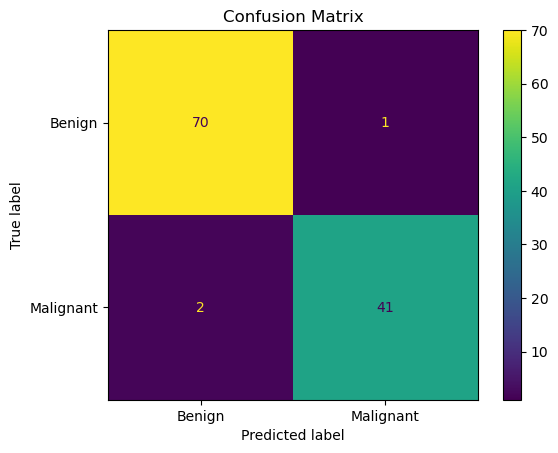

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test data
y_pred = model.predict(X_test)

# Create the confusion matrix from actual and predicted labels
cm = confusion_matrix(y_test, y_pred)

#disp = ConfusionMatrixDisplay(confusion_matrix=cm)
#disp.plot()

# Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [6]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9736842105263158


In [7]:
# True Positive (TP): You predicted malignant (1), and it is actually malignant.
# True Negative (TN): You predicted benign (0), and it is actually benign.
# False Positive (FP): You predicted malignant, but it is actually benign (Type I error).
# False Negative (FN): You predicted benign, but it is actually malignant (Type II error).

### Summary of Findings

# The logistic regression model showed high accuracy on the breast cancer dataset.
# The confusion matrix confirmed that the majority of predictions were correct.
# Logistic regression is a suitable and interpretable model for medical binary classification tasks.

